In [10]:
import numpy as np
import matplotlib.pyplot as plt
from utils import annotated_heatmap, analytical_policy_evaluation
from environments import CorridorEnvTerminalReward

In [11]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)

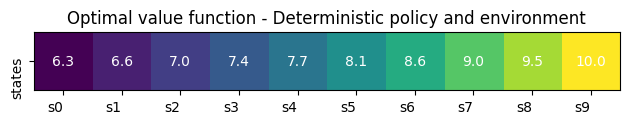

In [62]:
optimal_pi = [[0, 0, 1]]*n_states
v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=0.95)
annotated_heatmap([v_analytical], "Optimal value function - Deterministic policy and environment")

In [63]:
def argmax(q_values):
    """
    Takes in a list of q_values and returns the index of the item 
    with the highest value. Breaks ties randomly.
    returns: int - the index of the highest value in q_values
    """
    top_value = float("-inf")
    ties = []
    
    for i in range(len(q_values)):
        # if a value in q_values is greater than the highest value update top and reset ties to zero
        # if a value is equal to top value add the index to ties
        # return a random selection from ties.
        if q_values[i] > top_value:
            top_value = q_values[i]
            ties = [i]
        elif q_values[i] == top_value:
            ties.append(i)
    return np.random.choice(ties)

In [78]:
def epsilon_greedy_policy(q_values, epsilon: float = 0.1):
    return argmax(q_values) if np.random.rand() > epsilon else np.random.randint(len(q_values))

In [79]:
def sarsa(epsilon: float = 0.1, alpha: float = 0.9, gamma: float = 1.0, num_episodes: int = 10):
    # Create unique dictionaries for every state and action using list comprehension because dict is mutable
    returns = [[{"avg_return": 0.0, "freq": 0} for _ in range(n_actions)] for _ in range(n_states)]

    # Similarly for the q-table to be safe using list comprehension because list is mutable
    q = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]

    v = [0.0]*n_states # this can be defined using "*" instead of list comprehension because int is immutable
    
    err = []
    optimal_pi = [[0, 0, 1]]*n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)
    
    for e in range(num_episodes):
        done = False
        s = np.random.randint(0,env.nS)
        G = 0
        while not done:
            a = epsilon_greedy_policy(q[s], epsilon = epsilon)
            [_, s_, r, done] = env.step(s, a)[0]
            target = q[s_][a]*gamma*(not done) + r
            error = target - q[s][a]
            q[s][a] += alpha * error
            v[s] = max(q[s])
            s = s_
        err.append(sum((v_analytical - v)**2)/n_states)
    return v, err

Text(0, 0.5, 'MSE')

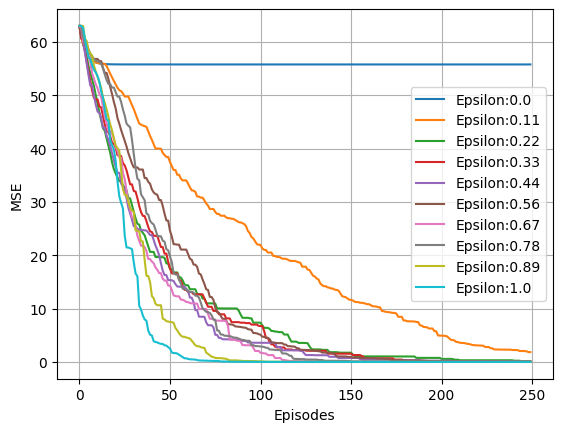

In [83]:
plt.grid()
for eps in np.linspace(0.0, 1.0, 10):
    _, sarsa_err = sarsa(epsilon = eps, alpha = 0.15, gamma=0.95, num_episodes=250)
    plt.plot(sarsa_err, label="Epsilon:"+str(round(eps, 2)))
plt.legend()
plt.xlabel("Episodes")
plt.ylabel("MSE")

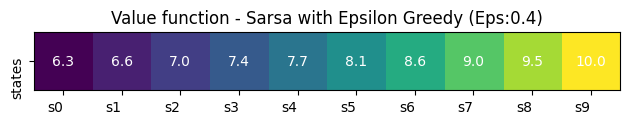

In [113]:
eps = 0.4
v, sarsa_err = sarsa(epsilon = eps, alpha = 0.15, gamma=0.95, num_episodes=100)
annotated_heatmap([v], f"Value function - Sarsa with Epsilon Greedy (Eps:{eps})")

# Expected Sarsa

In [104]:
def expected_sarsa(epsilon: float = 0.1, alpha: float = 0.9, gamma: float = 1.0, num_episodes: int = 10):

    # Similarly for the q-table to be safe using list comprehension because list is mutable
    q = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]

    v = [0.0]*n_states # this can be defined using "*" instead of list comprehension because int is immutable
    
    err = []
    optimal_pi = [[0, 0, 1]]*n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)
    
    for e in range(num_episodes):
        done = False
        s = np.random.randint(0,env.nS)
        G = 0
        while not done:
            a = epsilon_greedy_policy(q[s], epsilon = epsilon)
            [_, s_, r, done] = env.step(s, a)[0]
            policy = [(1-epsilon)/n_actions + epsilon if a_star==a else (1-epsilon)/n_actions for a_star in possible_actions]
            expected_val = np.dot(q[s_], policy)
            # print(q[s_], policy, expected_val)
            target = expected_val*gamma*(not done) + r
            error = target - q[s][a]
            q[s][a] += alpha * error
            v[s] = max(q[s])
            s = s_
        err.append(sum((v_analytical - v)**2)/n_states)
    return v, err

Text(0, 0.5, 'MSE')

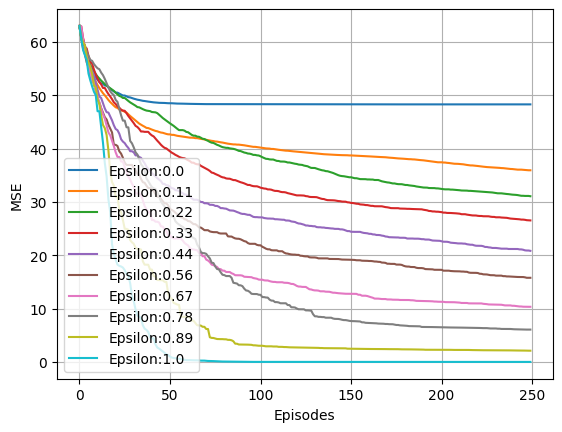

In [106]:
plt.grid()
for eps in np.linspace(0.0, 1.0, 10):
    _, exp_sarsa_err = expected_sarsa(epsilon = eps, alpha = 0.15, gamma=0.95, num_episodes=250)
    plt.plot(exp_sarsa_err, label="Epsilon:"+str(round(eps, 2)))
plt.legend()
plt.xlabel("Episodes")
plt.ylabel("MSE")

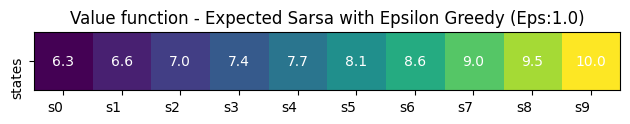

In [112]:
eps = 1.0
v, exp_sarsa_err = expected_sarsa(epsilon = eps, alpha = 0.15, gamma=0.95, num_episodes=100)
annotated_heatmap([v], f"Value function - Expected Sarsa with Epsilon Greedy (Eps:{eps})")

Text(0, 0.5, 'MSE')

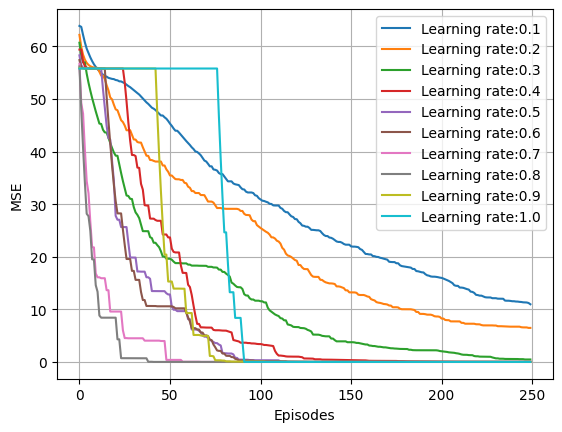

In [118]:
plt.grid()
for alpha in np.linspace(0.1, 1.0, 10):
    _, sarsa_err = sarsa(epsilon = 0.1, alpha = alpha, gamma=0.95, num_episodes=250)
    plt.plot(sarsa_err, label="Learning rate:"+str(round(alpha, 2)))
plt.legend()
plt.xlabel("Episodes")
plt.ylabel("MSE")

Text(0, 0.5, 'MSE')

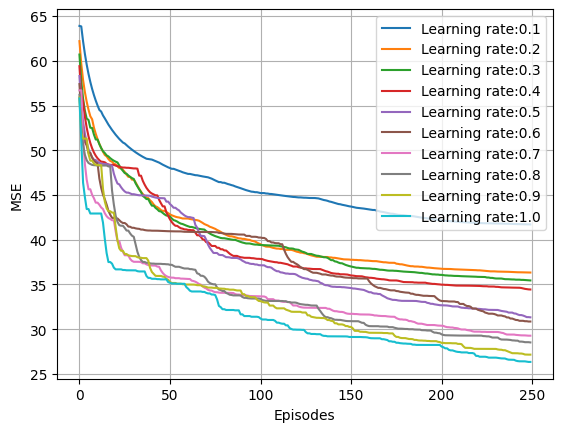

In [117]:
plt.grid()
for alpha in np.linspace(0.1, 1.0, 10):
    _, exp_sarsa_err = expected_sarsa(epsilon = 0.1, alpha = alpha, gamma=0.95, num_episodes=250)
    plt.plot(exp_sarsa_err, label="Learning rate:"+str(round(alpha, 2)))
plt.legend()
plt.xlabel("Episodes")
plt.ylabel("MSE")